In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA, FastICA
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import power_transform
from scipy import signal


#import lissa as li

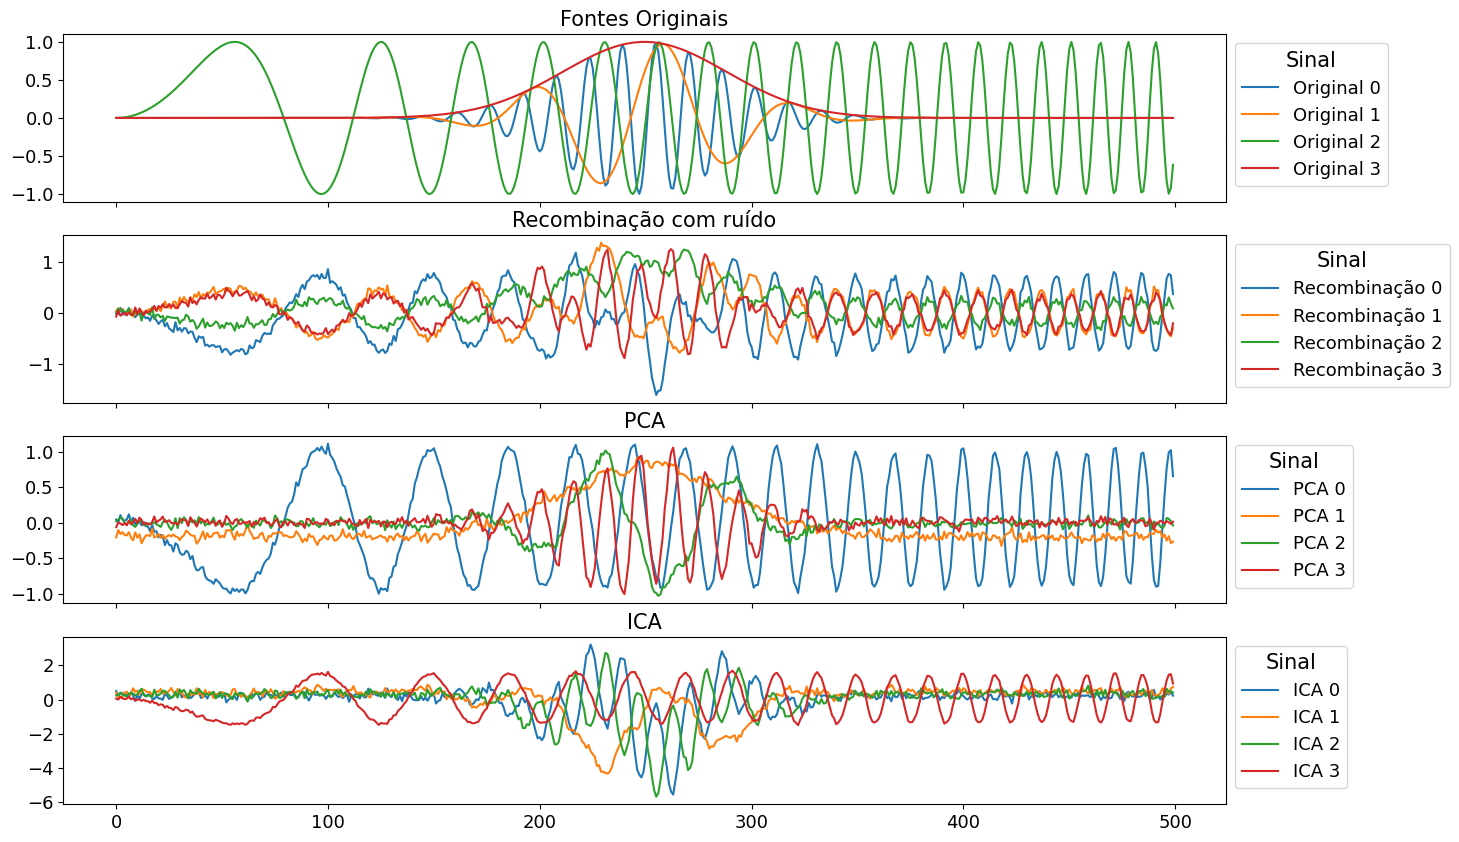

In [3]:
n = 500
tf = 5
t = np.linspace(0,tf,n)

window = np.exp((-(t-tf/2)*(t-tf/2))/0.3)

X = np.array(
    [
        np.sin(40*t)*window,
        np.sin(10*t+np.pi/4)*window,
        np.sin(5*t*t),
        np.ones(n)*window
    ]
)

nc = X.shape[0]


noiseamp = 0.05*np.max(X)
noise = noiseamp*np.random.randn(nc,n)


Q = np.linalg.qr(np.random.rand(nc,nc)).Q


S = pd.DataFrame(X.T@Q,columns=["Recombinação 0","Recombinação 1","Recombinação 2","Recombinação 3"])
Sn = (S+noise.T)
Z = Sn.ewm(alpha=0.8).mean()#((S-S.expanding().mean())/S.expanding().std()).fillna(0)

#Z.plot()

modelPCA = PCA(n_components=4)
recoverPCA = pd.DataFrame(modelPCA.fit_transform(Z),columns=["PCA 0","PCA 1","PCA 2","PCA 3"])


modelICA = FastICA(n_components=4)
recoverICA = pd.DataFrame(modelICA.fit_transform(Z),columns=["ICA 0","ICA 1","ICA 2","ICA 3"])

fig, axs = plt.subplots(4,1,sharex=True)
#plt.rcParams.update({'font.size': 20})

pd.DataFrame(X.T,columns=["Original 0","Original 1","Original 2","Original 3"]).plot(ax=axs[0],fontsize=13)

Sn.plot(ax=axs[1],figsize=(15,10),fontsize=13)

recoverPCA.plot(ax=axs[2],fontsize=13)
recoverICA.plot(ax=axs[3],fontsize=13)

titulos = ["Fontes Originais","Recombinação com ruído","PCA","ICA"]

for i in range(0,4):
    axs[i].set_title(titulos[i],fontsize=15)


for i in range(0,4):
    axs[i].legend(title="Sinal",loc='upper left',bbox_to_anchor=(1, 1),fontsize=13,title_fontsize=15)




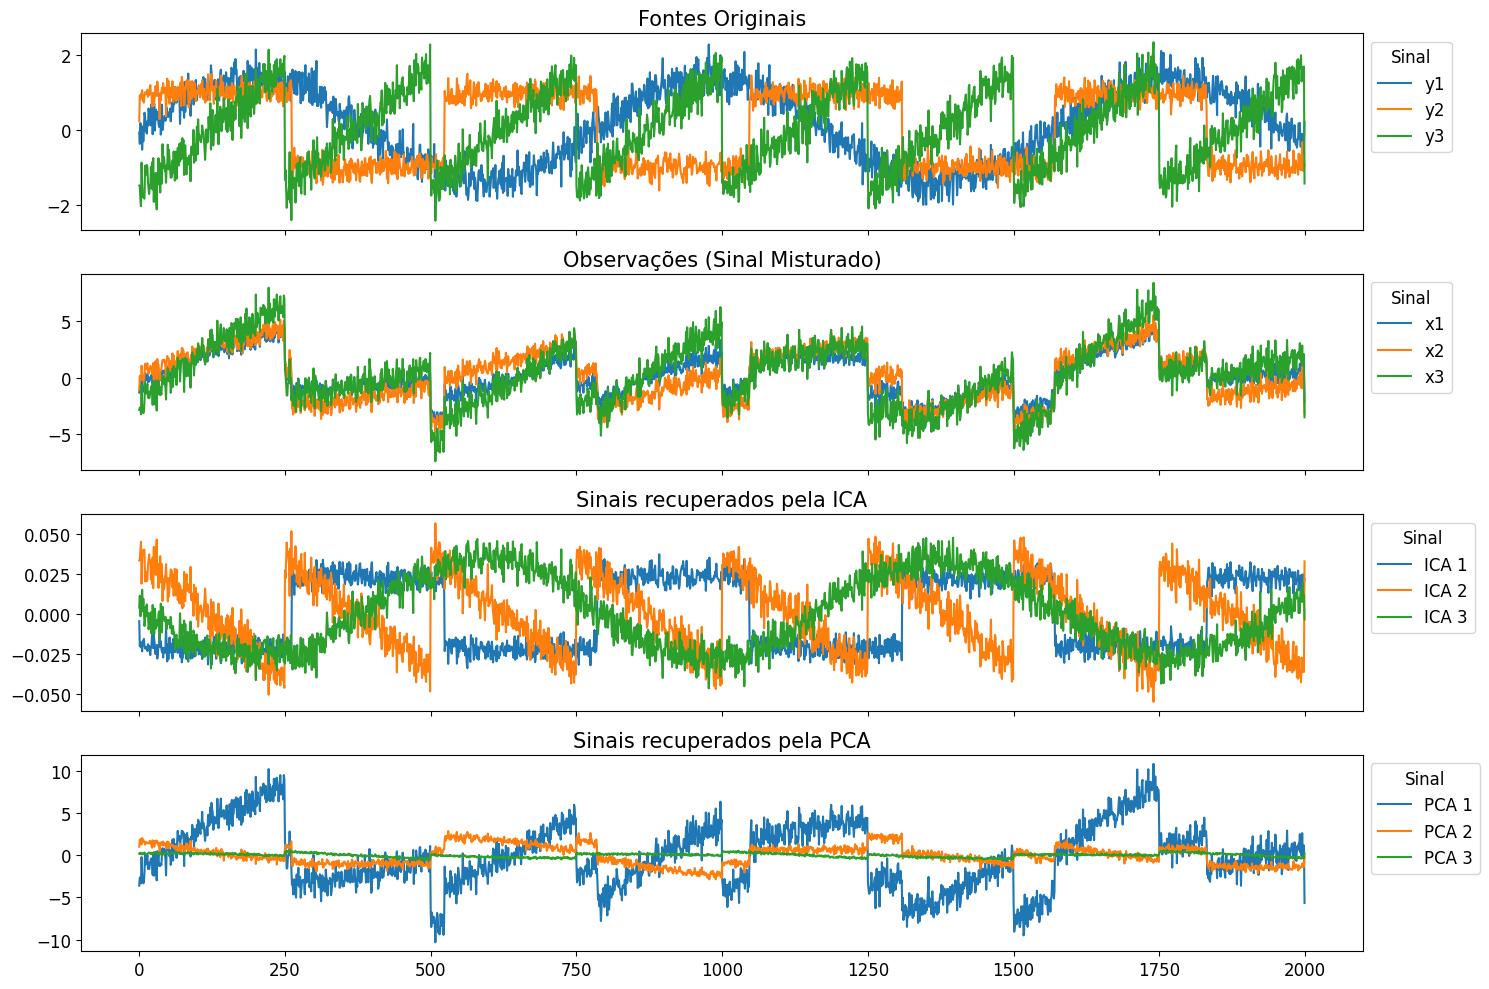

In [4]:
np.random.seed(19640822)
n_samples = 2000
time = np.linspace(0, 8, n_samples)

s1 = np.sin(2 * time)  # Signal 1 : sinusoidal signal
s2 = np.sign(np.sin(3 * time))  # Signal 2 : square signal
s3 = signal.sawtooth(2 * np.pi * time)  # Signal 3: saw tooth signal

S = np.c_[s1, s2, s3]
S += 0.2 * np.random.normal(size=S.shape)  # Add noise

S /= S.std(axis=0)  # Standardize data
# Mix data
A = np.array([[1, 1, 1], [0.5, 2, 1.0], [1.5, 1.0, 2.0]])  # Mixing matrix
X = np.dot(S, A.T)  # Generate observations


# Compute ICA
ica = FastICA(n_components=3, whiten="arbitrary-variance")
S_ = ica.fit_transform(X)  # Reconstruct signals
A_ = ica.mixing_  # Get estimated mixing matrix

# We can `prove` that the ICA model applies by reverting the unmixing.
assert np.allclose(X, np.dot(S_, A_.T) + ica.mean_)

# For comparison, compute PCA
pca = PCA(n_components=3)
H = pca.fit_transform(X)  # Reconstruct signals based on orthogonal components


fig,axs = plt.subplots(4,1,figsize=(15,10),sharex=True)

X = pd.DataFrame(X,columns=["x1","x2","x3"])
S = pd.DataFrame(S,columns=["y1","y2","y3"])
S_ = pd.DataFrame(S_,columns=["ICA 1","ICA 2","ICA 3"])
H = pd.DataFrame(H,columns=["PCA 1","PCA 2","PCA 3"])

models = [S, X, S_, H]
names = [
    "Fontes Originais",
    "Observações (Sinal Misturado)",
    "Sinais recuperados pela ICA",
    "Sinais recuperados pela PCA",
]
colors = ["red", "steelblue", "orange"]
i = 0
for i,(model, name) in enumerate(zip(models, names), 0):
    model.plot(ax=axs[i],fontsize=11)
    axs[i].legend(title="Sinal", loc='upper left',bbox_to_anchor=(1, 1),title_fontsize=12, fontsize=12)
    axs[i].set_title(name,fontsize=15)
    axs[i].tick_params(labelsize=12)


    # for sig, color in zip(model.T, colors):
    #     axs[i].plot(sig, color=color)
    #     axs[i].set_title(name,fontsize=15)
    #     
plt.tight_layout()
plt.show()

<Axes: >

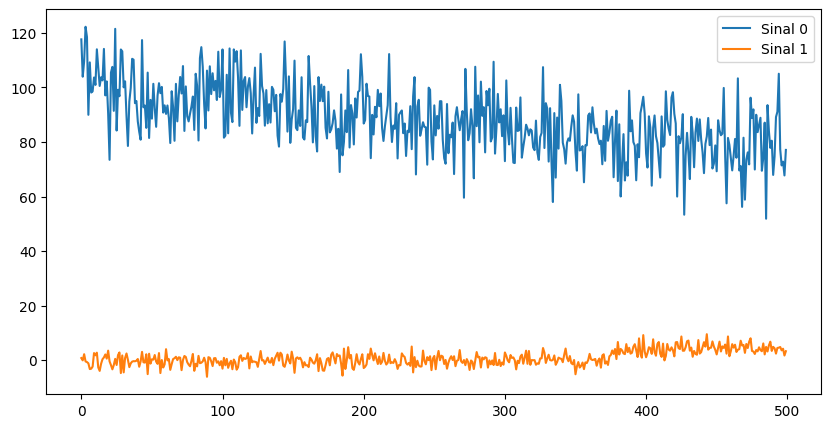

In [41]:
n = 500
tf = 5
t = np.linspace(0,tf,n)

window = np.exp((-(t-tf/2)*(t-tf/2))/0.1)

np.random.seed(0)

noiseAmp = 0.1
decay = -0.05

windowAmp = 0.2
VA1 = 100
VA2 = 20

# V1 = VA1*((windowAmp*window)+np.exp(decay*t)+noiseAmp*np.random.randn(n))
# V2 = VA2*((windowAmp*window)+np.exp(decay*t)+noiseAmp*np.random.randn(n))
#V2 = np.random.randn(n)*np.exp(0.04*t)

V1 = VA1*(np.exp(decay*t)+noiseAmp*np.random.randn(n))
V2 = VA2*(noiseAmp*np.random.randn(n))
#V1[int(np.floor(1*n/4)):int(np.floor(3*n/4))]+=10 

V2[int(np.floor(3*n/4)):]+=VA2/5
#V2[125:375]-=3

#V = pd.DataFrame(V1,index=t,columns=["Sinal 0"])
V = pd.DataFrame(np.array([V1, V2]).T,columns=["Sinal 0","Sinal 1"])
#np.concatenate(np.zeros((2,250)),2*np.ones((250,2)))



V.plot(figsize=(10,5))

array([[<Axes: title={'center': 'Sinal 0'}>,
        <Axes: title={'center': 'Sinal 1'}>]], dtype=object)

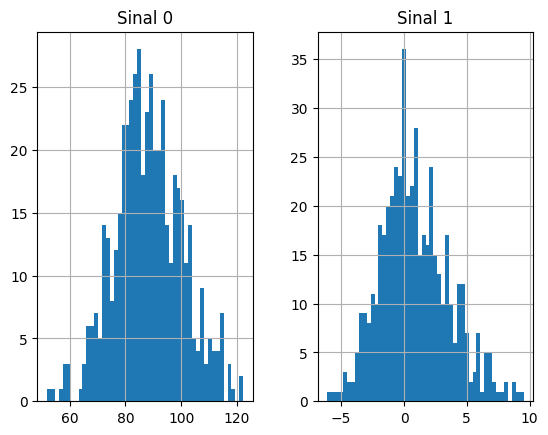

In [42]:
V.hist(bins=50)#.cumsum(axis=1)

<Axes: >

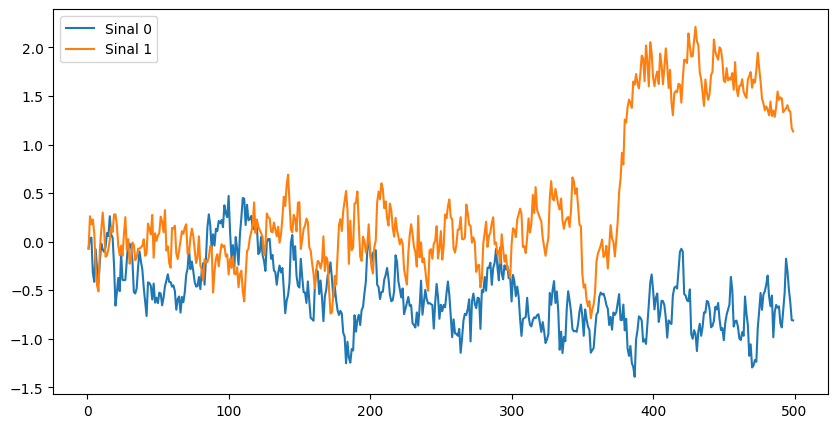

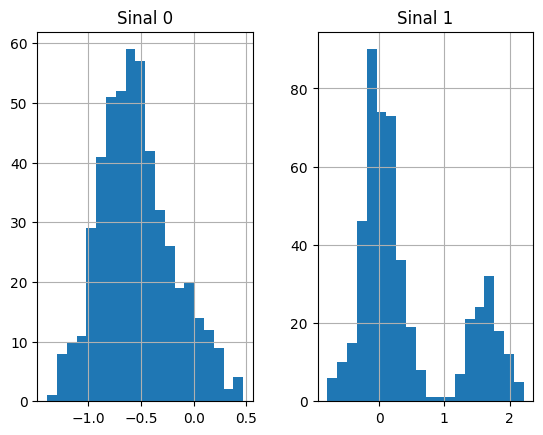

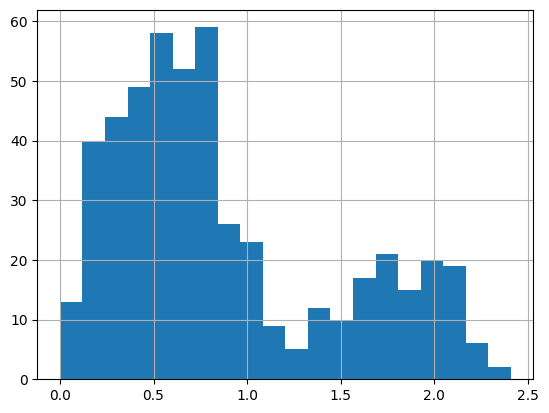

In [43]:
Z = ((V.ewm(span=10).mean()-V.expanding().median())/V.expanding().std())
Z.plot(figsize=(10,5))

Z.hist(bins=20)#.pow(2).sum(axis=1).pow(1/2).hist(bins=20)

squared = Z.pow(2).sum(axis=1).pow(1/2)
plt.figure()
squared.hist(bins=20)

Text(0.5, 1.0, 'Hidden Markov applied to norm-2 PCA components')

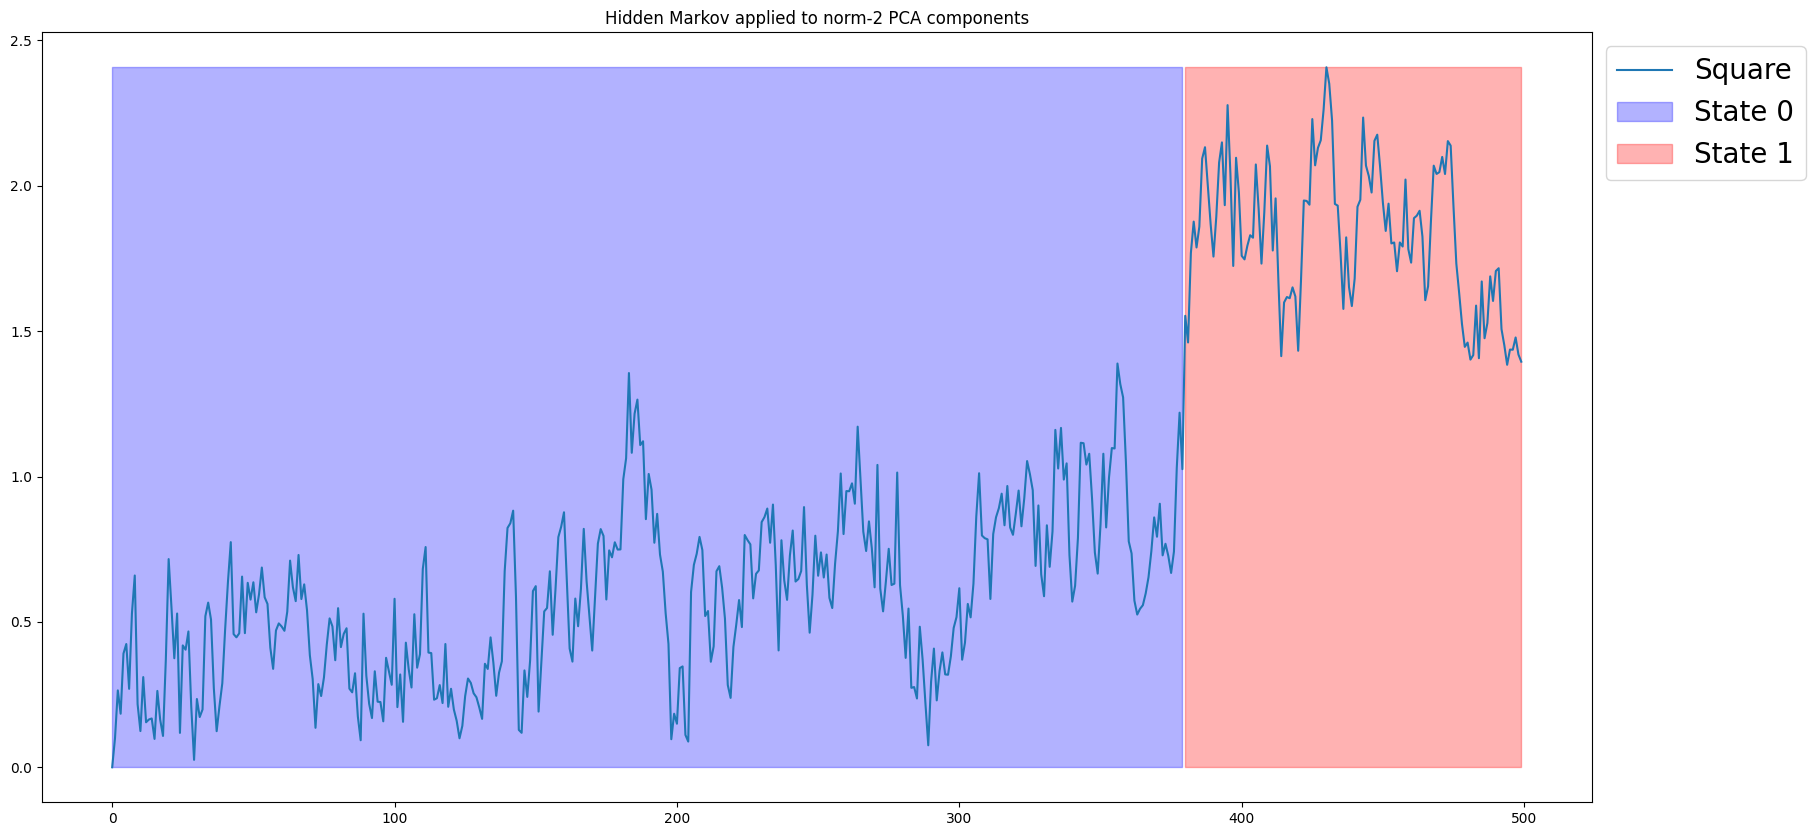

In [44]:

# Exemplo de estados ao longo do tempo
n = 2
states = range(0,n)

# Gerando cores automáticas com base no número de estados
num_states = len(np.unique(states))
cmap = plt.get_cmap('bwr', num_states)  # Escolhe um colormap com num_states cores

cmap

model = GaussianHMM(n_components=n,covariance_type="full",random_state=np.random.seed(0))
model.fit(squared.to_numpy().reshape(-1,1))

states = model.predict(squared.to_numpy().reshape(-1,1))

final = pd.DataFrame(np.array([squared, states]).T,columns=["Square","STS"])

fig,axs = plt.subplots(1,1)
final["Square"].plot(ax=axs,figsize=(20,10))


for state in range(0,n):
            color = cmap(state)  # Pega uma cor automática para cada estado
            axs.fill_between(final.index,np.min(squared), np.max(squared), where=(final["STS"] == state), 
                            color=color, alpha=0.3, label=f"State {state}")

            axs.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=20)

plt.title("Hidden Markov applied to norm-2 PCA components")



In [9]:
# k = 5

# dataPD = pd.DataFrame()
# for i in range(0,k):
#     dataPD[f"Square_{i}"] = data.shift(i)

# data2reg = dataPD.dropna(axis=0).shift(-1).dropna()
# y = data.shift(-k).dropna()

# A = data2reg.T@data2reg
# b = data2reg.T.to_numpy()@y

# np.linalg.solve(A,b)

In [10]:
# import numpy as np

# from sklearn.decomposition import PCA, FastICA

# rng = np.random.RandomState(42)
# S = rng.standard_t(1.5, size=(20000, 2))
# S[:, 0] *= 2.0

# # Mix data
# A = np.array([[1, 1], [0, 2]])  # Mixing matrix

# X = np.dot(S, A.T)  # Generate observations

# pca = PCA()
# S_pca_ = pca.fit(X).transform(X)

# ica = FastICA(random_state=rng, whiten="arbitrary-variance")
# S_ica_ = ica.fit(X).transform(X)  # Estimate the sources

# plt.figure(figsize=(15,5))
# plt.plot(S)